1.Importation

In [1]:
from sklearn.metrics._plot.confusion_matrix import confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score ,confusion_matrix,classification_report
import pickle


ModuleNotFoundError: No module named 'imblearn'

2.Data Loading


In [ ]:
df =pd .read_csv("/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
df.shape

(7043, 21)

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df = df.drop(columns=["customerID"])

In [ ]:
df[df["TotalCharges"]==' ']

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [ ]:
len(df[df["TotalCharges"]==' '])

11

In [ ]:
df["TotalCharges"]=df["TotalCharges"].str.replace(" ","0.0")

In [ ]:
df["TotalCharges"]=df["TotalCharges"].astype(float)

In [ ]:
numerical_feature=["tenure","MonthlyCharges","TotalCharges"]

for col in df.columns:
  if col not in numerical_feature:
    print(col, df[col].unique())
    print("-"*50)


gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
--------------------------------------------------
TechSupport ['No' 'Yes' 'No internet service']
--------------------------------------------------
StreamingTV ['No' 'Yes' 'No internet 

In [ ]:
print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
#Target column
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


**Notes:**
1.   Customer ID removed

2.    Missing values in TotalCharges column were replaced with 0
1.   No missing values
2.   Class imbalance identified in the target






## 3. Exploratory Data Analysis (EDA)

EDA helps us understand the **structure, distributions, and relationships** within the data before building any model. In this section we will:

- Examine the **target variable** (Churn) to check for class imbalance
- Analyse the **three numerical features**: `tenure`, `MonthlyCharges`, and `TotalCharges`
- Explore **categorical features** to see how different service choices and demographics are distributed
- Measure **correlations** between numerical features

A thorough EDA guides every preprocessing and modelling decision that follows.

**3.EDA**

In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


###  Summary Statistics — Key Observations

| Feature | Insight |
|---|---|
| `tenure` | Ranges from **0 to 72 months**; mean ≈ 32 months — many new *and* long-term customers |
| `MonthlyCharges` | Mean ≈ \$64.8 with high variance (SD ≈ \$30) — wide pricing spectrum |
| `TotalCharges` | Highly right-skewed (min 0, max \$8684) because new customers have tiny totals |

> **Implication:** Skewed distributions may affect some models; tree-based methods (our choice) handle this natively.

**Numerical Features-Analysis**

### Numerical Features — Distribution Analysis

We plot **histograms with KDE** (Kernel Density Estimate) to visualise each feature's distribution shape, and mark the **mean** (red dashed) and **median** (green solid) to spot skewness.

We also draw **box plots** to detect outliers visually.

> A large gap between mean and median signals skewness; outliers appear as dots beyond the whiskers.

In [ ]:
def plot_histogram(df,column_name):
  plt.figure(figsize=(5,3))
  sns.histplot(df[column_name],kde=True)
  plt.title(f"Distribution of {column_name}")

  col_mean=df[column_name].mean()
  col_median=df[column_name].median()

  plt.axvline(col_mean,color="red",linestyle="--",label="Mean")
  plt.axvline(col_median,color="green",linestyle="-",label="Median")

  plt.show()

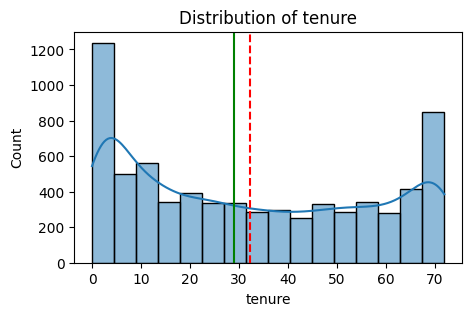

In [ ]:
plot_histogram(df,"tenure")

**`tenure` — Interpretation:**
- Distribution is **bimodal** (U-shaped): many customers either left very early or have been with the company for a long time.
- The gap between the mean and median is small, so the distribution is not strongly skewed.
- **Business insight:** A spike at low tenure suggests a churn-prone onboarding phase.

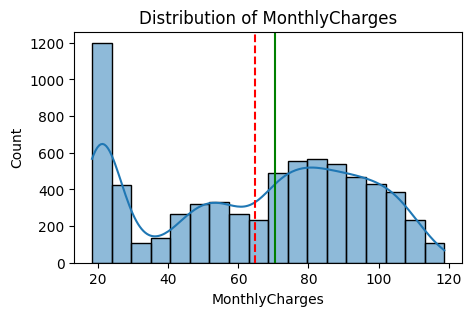

In [ ]:
plot_histogram(df,"MonthlyCharges")

**`MonthlyCharges` — Interpretation:**
- Roughly **uniform to slightly right-skewed** with a cluster of low-price plans near \$20.
- Customers spread broadly across price tiers, suggesting diverse plan offerings.
- **Business insight:** Higher monthly charges might correlate with higher churn — higher-paying customers are more price-sensitive.

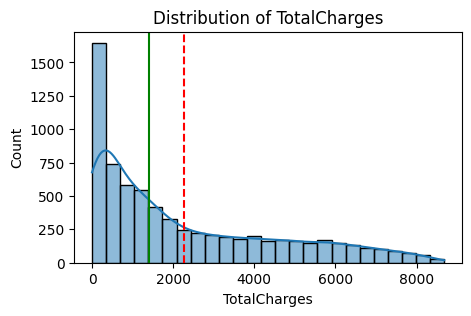

In [ ]:
plot_histogram(df,"TotalCharges")

**`TotalCharges` — Interpretation:**
- Strongly **right-skewed**: most customers have low total charges (new customers), while a long tail represents long-tenure customers.
- This skew is *expected* — `TotalCharges ≈ tenure × MonthlyCharges`.
- **Note:** Skewness here is a structural feature, not noise — no transformation is strictly required for tree-based models.

In [ ]:
def plot_boxplot(df,column_name):
  plt.figure(figsize=(5,3))
  sns.boxplot(y=df[column_name])
  plt.title(f"Boxplot of {column_name}")
  plt.ylabel(column_name)
  plt.show()

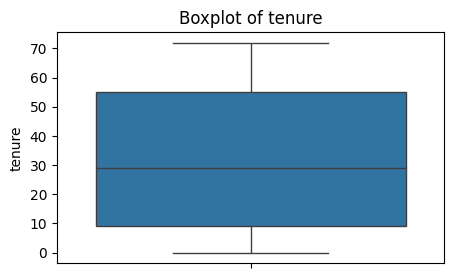

In [ ]:
plot_boxplot(df,"tenure")

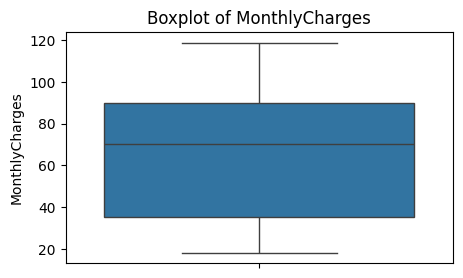

In [ ]:
plot_boxplot(df,"MonthlyCharges")

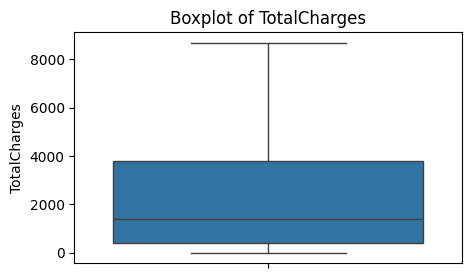

In [ ]:
plot_boxplot(df,"TotalCharges")

### Box Plot Interpretation

Box plots confirm what histograms showed:
- **`tenure`**: No extreme outliers; interquartile range spans roughly 10–55 months.
- **`MonthlyCharges`**: No strong outliers; relatively even spread.
- **`TotalCharges`**: Long upper whisker confirms the right skew — a few high-value, long-tenure customers pull the distribution.

---
### Correlation Heatmap

A heatmap of Pearson correlations between the three numerical features shows how strongly they move together (values close to **+1** = strong positive correlation, **0** = no linear relationship).

Correlation Heatmap

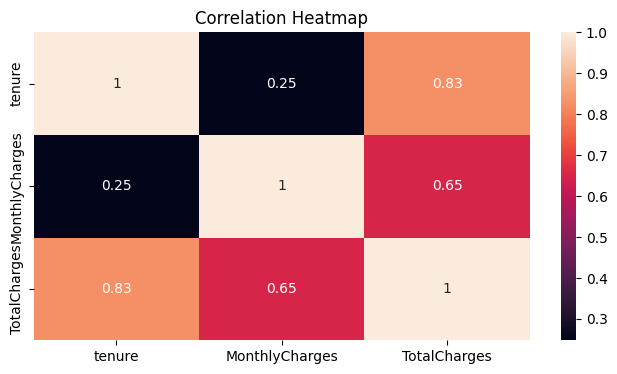

In [ ]:
plt.figure(figsize=(8,4))
sns.heatmap(df[["tenure","MonthlyCharges","TotalCharges"]].corr(),annot=True)
plt.title("Correlation Heatmap")
plt.show()


**Correlation Results — Interpretation:**

| Pair | Expected Correlation | Reason |
|---|---|---|
| `tenure` ↔ `TotalCharges` | **High (~0.83)** | Longer customers pay more overall |
| `MonthlyCharges` ↔ `TotalCharges` | **Moderate (~0.65)** | Higher monthly plans raise lifetime spend |
| `tenure` ↔ `MonthlyCharges` | **Low (~0.25)** | Plan price is mostly independent of how long someone has been a customer |

> **Multicollinearity note:** The high correlation between `tenure` and `TotalCharges` is expected. For linear models, dropping one would be advisable; for Random Forest, it is not an issue.

**Categorical Features-Analysis**

### Categorical Features — Count Plot Analysis

Count plots show the **frequency of each category** for every categorical variable. Key things to look for:

- **Imbalanced categories** — one dominant class can bias a model.
- **Rare categories** — categories with very few observations may not generalise well.
- **Target-related patterns** — if a category appears to cluster with churners, it deserves further analysis.

The features examined include demographics (`gender`, `SeniorCitizen`, `Partner`, `Dependents`) and service subscriptions (`PhoneService`, `InternetService`, `Contract`, `PaymentMethod`, etc.).

In [ ]:
object_cols=["SeniorCitizen"] + df.select_dtypes(include="object").columns.to_list()

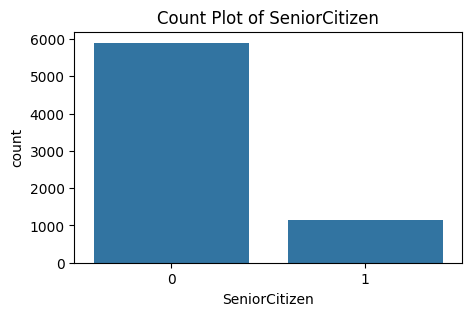

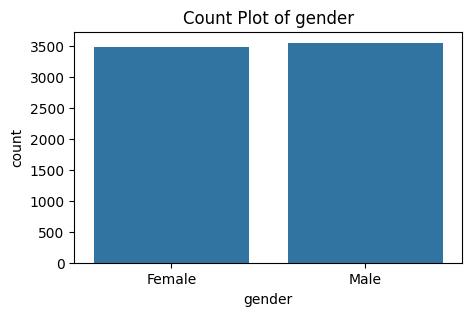

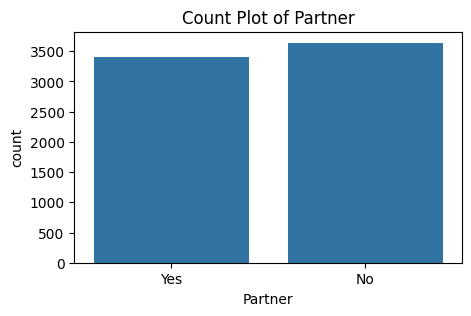

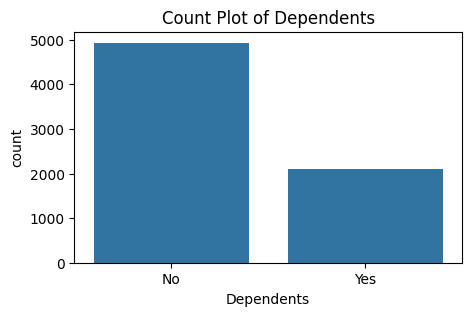

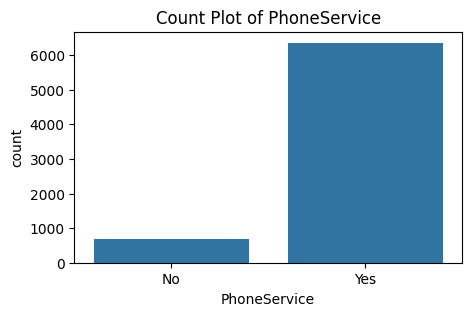

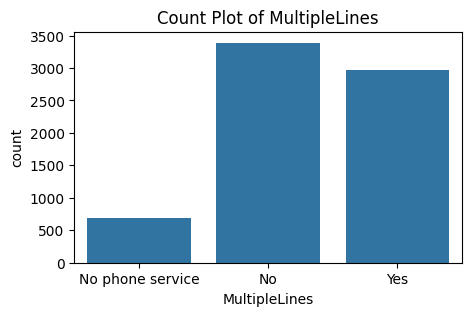

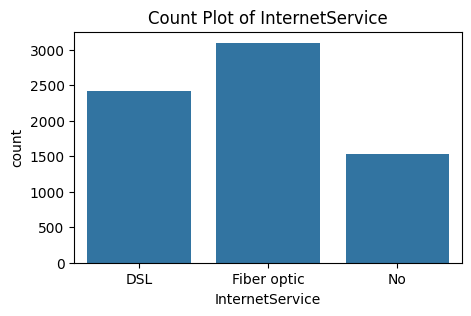

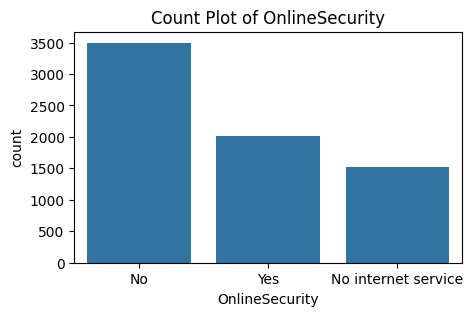

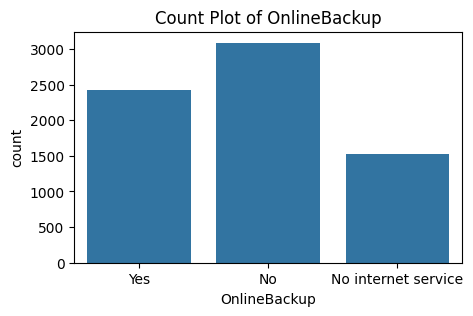

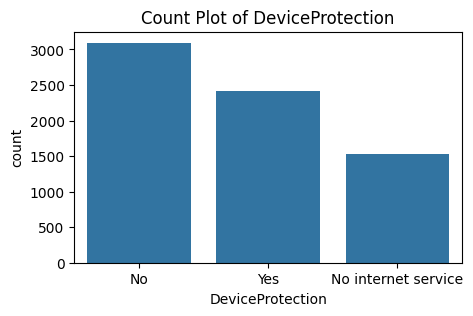

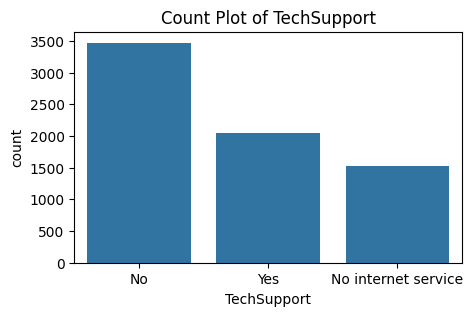

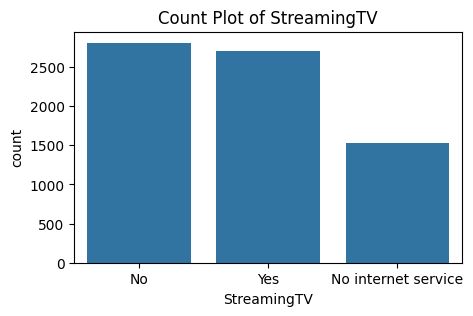

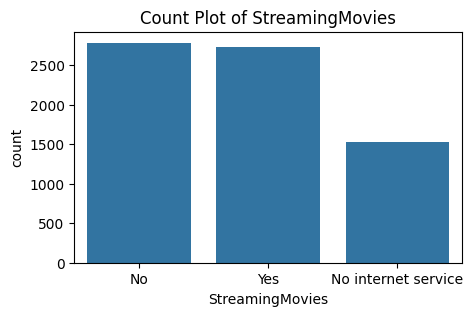

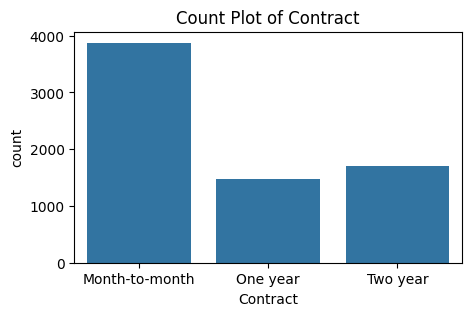

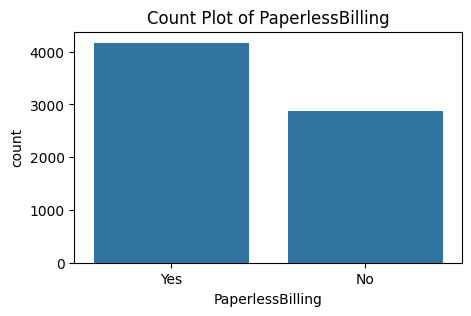

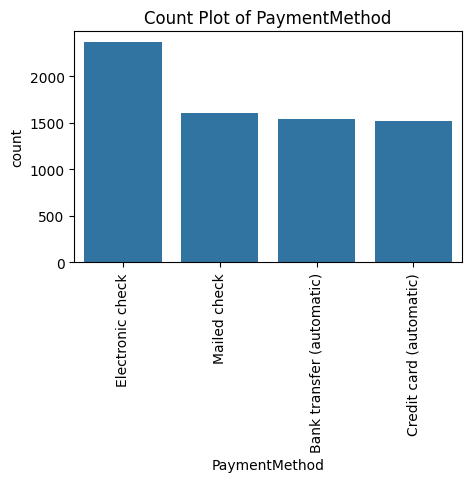

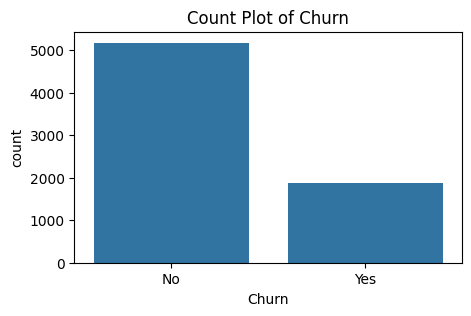

In [ ]:
for col in object_cols:
  plt.figure(figsize=(5,3))
  sns.countplot(data=df,x=col)
  plt.title(f"Count Plot of {col}")
  if col=="PaymentMethod":
    plt.xticks(rotation=90)
  plt.show()

**Categorical Features — Key Observations:**

| Feature | Observation | Business Implication |
|---|---|---|
| `gender` | Roughly **50/50 split** — well balanced | Gender alone is unlikely a strong predictor |
| `SeniorCitizen` | ~**84% non-senior** — highly imbalanced | Seniors are a minority but potentially higher-risk group |
| `Partner` / `Dependents` | More customers without dependents | Customers with dependents may be more stable (tied to a plan) |
| `Contract` | Month-to-month dominates (~55%) | Short-term contracts = higher churn risk |
| `PaymentMethod` | Electronic check is most common | Payment friction may correlate with churn |
| `InternetService` | Fibre optic has highest count | Fibre users may have higher expectations → more likely to churn |
| `TechSupport` / `OnlineSecurity` | Most customers opted **out** | Opting out of security/support may link to lower engagement and higher churn |

> **Next step:** These patterns motivate encoding all categorical variables before modelling, which we do in Section 4.

###  Target Variable — Churn Distribution

Recall from data loading:
- **No Churn (0):** ~73% of customers
- **Churn (1):** ~27% of customers

This is a **moderately imbalanced** dataset. Training a model on raw data would bias it toward predicting "No Churn." This is why we apply **SMOTE** (Synthetic Minority Over-sampling Technique) in the preprocessing step to balance the training set.

**4.Data Preprocessing**

Label encoding of target column

In [ ]:
df["Churn"] = df["Churn"].replace({"Yes":1,"No":0})

/tmp/ipykernel_2351/3368294369.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Churn"] = df["Churn"].replace({"Yes":1,"No":0})


In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
print(df["Churn"].value_counts())


Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
object_cols.remove("SeniorCitizen")

In [ ]:
encoders={}
for column in object_cols:
  label_encoder=LabelEncoder()
  df[column] = label_encoder.fit_transform(df[column])
  encoders[column] = label_encoder

with open("encoders.pkl","wb")as f:
  pickle.dump(encoders, f)

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


**Training and test data split**

In [ ]:
X=df.drop(columns=["Churn"])
y=df["Churn"]

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
print(y_train.value_counts())

Churn
0    4138
1    1496
Name: count, dtype: int64


imbalanced data

In [ ]:
smote=SMOTE(random_state=42)

In [ ]:
X_train_smote,y_train_smote = smote.fit_resample(X_train,y_train)

In [ ]:
print(y_train_smote.value_counts())

Churn
0    4138
1    4138
Name: count, dtype: int64


**5.Model Training**

In [ ]:
models={
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost" : XGBClassifier(random_state=42)
}

In [ ]:
#cross validation
cv_scores = {}

for model_name,model in models.items():
  print(f"Training {model_name} with default parameters")
  scores=cross_val_score(model,X_train_smote,y_train_smote,cv=5,scoring="accuracy")
  cv_scores[model_name]=scores
  print(f"{model_name} cross-validation accuracy: {np.mean(scores):.3f}")
  print("-"*70)

Training Decision Tree with default parameters
Decision Tree cross-validation accuracy: 0.778
----------------------------------------------------------------------
Training Random Forest with default parameters
Random Forest cross-validation accuracy: 0.841
----------------------------------------------------------------------
Training XGBoost with default parameters
XGBoost cross-validation accuracy: 0.831
----------------------------------------------------------------------


Random Forest gives the hieghest accuracy

In [ ]:
rfc=RandomForestClassifier(random_state=42)
rfc.fit(X_train_smote,y_train_smote)

RandomForestClassifier(random_state=42)

In [ ]:
print(y_test.value_counts())

Churn
0    1036
1     373
Name: count, dtype: int64


**6.Model Evaluation**

In [ ]:
y_test_pred = rfc.predict(X_test)

print("accuracy Score:\n",accuracy_score(y_test,y_test_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_test_pred))
print("Classifixation Report:\n",classification_report(y_test,y_test_pred))

accuracy Score:
 0.7785663591199432
Confusion Matrix:
 [[878 158]
 [154 219]]
Classifixation Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1036
           1       0.58      0.59      0.58       373

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



In [ ]:
model_data = {"model":rfc,"features_names":X.columns.tolist()}
with open("customer_churn_model.pkl","wb") as f:
          pickle.dump(model_data,f)

**7.Load the saved model and build a Prediction System**

In [ ]:
with open("customer_churn_model.pkl","rb") as f:
        model_data=pickle.load(f)

loaded_model = model_data["model"]
feature_names = model_data["features_names"]

In [ ]:
print(loaded_model)

RandomForestClassifier(random_state=42)


In [ ]:
print(feature_names)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [ ]:
input_data = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 1,
    'PhoneService': 'No',
    'MultipleLines': 'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 29.85,
    'TotalCharges': 29.85
}


input_data_df = pd.DataFrame([input_data])

with open("encoders.pkl", "rb") as f:
  encoders = pickle.load(f)



for column, encoder in encoders.items():
  input_data_df[column] = encoder.transform(input_data_df[column])


prediction = loaded_model.predict(input_data_df)
pred_prob = loaded_model.predict_proba(input_data_df)

print(prediction)

# results
print(f"Prediction: {'Churn' if prediction[0] == 1 else 'No Churn'}")
print(f"Prediciton Probability: {pred_prob}")

[0]
Prediction: No Churn
Prediciton Probability: [[0.78 0.22]]
